In [93]:
"""run BC across all sessions"""

import os, sys
from pathlib import Path
import bombcell as bc
import bombcell.quality_metrics as qm
sys.path.append(r"c:\Users\Jasmine\Documents\GitHub\JAL2_subgoal_pipeline")
from behave_analysis.postprocess.bc_process.bombcell_utils import get_waveform_peak_channel_safe
qm.get_waveform_peak_channel = get_waveform_peak_channel_safe
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

"""Set up params"""
def get_params(ks_dir, raw_file_path, meta_file_path, mouse):
    param = bc.get_default_parameters(ks_dir, 
                                    raw_file=raw_file_path,
                                    meta_file=meta_file_path,
                                    kilosort_version=2)
    # general params:
    if mouse == "JAL003":
        param["probeType"] = 1  # NP1.0
    else:
        param["probeType"] = 2  # NP2.0

    JR_params = np.load(r"Z:/Jasmine_Laurence/bombcell/bombcell_params.npy", allow_pickle=True).item()
    # Update param with JR_params
    for key, value in JR_params.items():
        param[key] = value

    param["n_spikes"] = 100 # very short sweeps so keep this low low low
        
    return param

"""Run bombcell"""

hist_dict = {}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"] # list of 6 distinct hex colors
metrics = {"nPeaks": 1,
        "nTroughs": 1,
        "waveformBaselineFlatness": .02,
        "waveformDuration_peakTrough": 50,
        "scndPeakToTroughRatio": .02,
        "spatialDecaySlope": .002,
        "peak1ToPeak2Ratio": 5,
        "mainPeakToTroughRatio": .1,
        "rawAmplitude": 15,
        "signalToNoiseRatio": 5,
        "fractionRPVs_estimatedTauR": .05,
        "nSpikes": 10000,
        "presenceRatio": .01,
        "percentageSpikesMissing_gaussian": 1}

base_path = Path(r"Z:/Jasmine_Laurence/Experimental_Data/")


In [107]:
"""Param iteration"""
# "detect_threshold": 6
# "projection_threshold": [8, 4]  # Spike detection threshold
# "AUCsplit": 0.8
# "nblock": 5
GRID = {
    "detect_threshold": [5, 6, 7],
    "AUCsplit": [0.7, 0.8, 0.9],
    "projection_threshold": [[7, 3], [8, 4], [9, 5]],
    "nblocks": [1, 5, 10],
}
it = 0
auc_list = []
dt_list = []
pt_list = []
nb_list = []

for dt in GRID["detect_threshold"]:
    for auc in GRID["AUCsplit"]:
        for pt in GRID["projection_threshold"]:
            for nb in GRID["nblocks"]:
                if (dt == 6) and (auc == 0.8) and (pt == [8, 4]) and (nb == 5):
                    used_it = it
                it += 1     
                auc_list.append(auc)
                dt_list.append(dt)
                pt_list.append(pt[0])
                nb_list.append(nb)
# add entry for default
auc_list.append(0)
dt_list.append(0)
pt_list.append(0)
nb_list.append(0)


In [103]:
for mouse in ["JAL003"]:#["JAL003","JAL006", "JAL007"]:
    mouse_folder = os.path.join(base_path, mouse)
    for session in os.listdir(mouse_folder):
        session_folder = os.path.join(mouse_folder, session)
        # find dir that end in "_g0"
        if os.path.isdir(session_folder):
            for d in os.listdir(session_folder):
                if os.path.isdir(os.path.join(session_folder, d)) and d.endswith("_g0"):
                    imec_folder = os.path.join(session_folder, d, d + "_imec0")
                    for e in os.listdir(imec_folder):
                        if e == "KS_sweep":
                            raw_file = os.path.join(imec_folder, d + "_t0.imec0.ap.bin")
                            meta_file = os.path.join(imec_folder, d + "_t0.imec0.ap.meta")
                            results = {'unit_num': [], 'n_good_units': [], 'n_mua_units': [], 'n_noise_units': []}
                            run_folder_names = []
                            if mouse == "JAL007":
                                for i in range(it):
                                    run_folder_names.append(f"run_00{i}" if i < 10 else f"run_0{i}" if i < 100 else f"run_{i}")
                            if mouse == "JAL003" or mouse == "JAL006":
                                for l in ["A", "B", "C"]:
                                    for i in range(int(it/3)):
                                        run_folder_names.append(f"run{l}_00{i}" if i < 10 else f"run{l}_0{i}" if i < 100 else f"run{l}_{i}")
                            run_folder_names.append("run_default")
                            for run in run_folder_names:
                                ks_dir = os.path.join(imec_folder, e, run, "sorter_output", "sorter_output")

                                # Set bombcell's output directory
                                save_path = Path(ks_dir) / "bombcell"
                                if not os.path.exists(save_path):
                                    print(f"You have not yet run bombcell for session {session} ({d}): {run}. Go run it on the cluster!")

                                else:
                                    types = pd.read_csv(os.path.join(ks_dir, "cluster_bc_unitType.tsv"), sep='\t')
                                    results['unit_num'].append(len(types))
                                    results['n_good_units'].append(np.sum(types['bc_unitType'].to_numpy() == "GOOD"))
                                    results['n_mua_units'].append(np.sum(types['bc_unitType'].to_numpy() == "MUA"))
                                    results['n_noise_units'].append(np.sum(types['bc_unitType'].to_numpy() == "NOISE"))
                                    chosen = np.ones(len(types), dtype=bool)  # types['bc_unitType'].to_numpy() == "GOOD"

In [104]:
import matplotlib.colors as mcolors

def three_shades(base_color, light_mix=0.65, dark_mix=0.35):
    """
    Returns [light, mid, dark] hex colors from one base color.
    light_mix: how much white to mix into the light shade
    dark_mix: how much black to mix into the dark shade
    """
    c = np.array(mcolors.to_rgb(base_color))
    light = c + (1 - c) * light_mix   # mix toward white
    mid = c
    dark = c * dark_mix               # mix toward black
    return [mcolors.to_hex(x) for x in (light, mid, dark)]

In [112]:
use_color

array([ 1,  5, 10,  1,  5, 10,  1,  5, 10,  1,  5, 10,  1,  5, 10,  1,  5,
       10,  1,  5, 10,  1,  5, 10,  1,  5, 10,  1,  5, 10,  1,  5, 10,  1,
        5, 10,  1,  5, 10,  1,  5, 10,  1,  5, 10,  1,  5, 10,  1,  5, 10,
        1,  5, 10,  1,  5, 10,  1,  5, 10,  1,  5, 10,  1,  5, 10,  1,  5,
       10,  1,  5, 10,  1,  5, 10,  1,  5, 10,  1,  5, 10,  0])

Text(0, 0.5, 'Good Units')

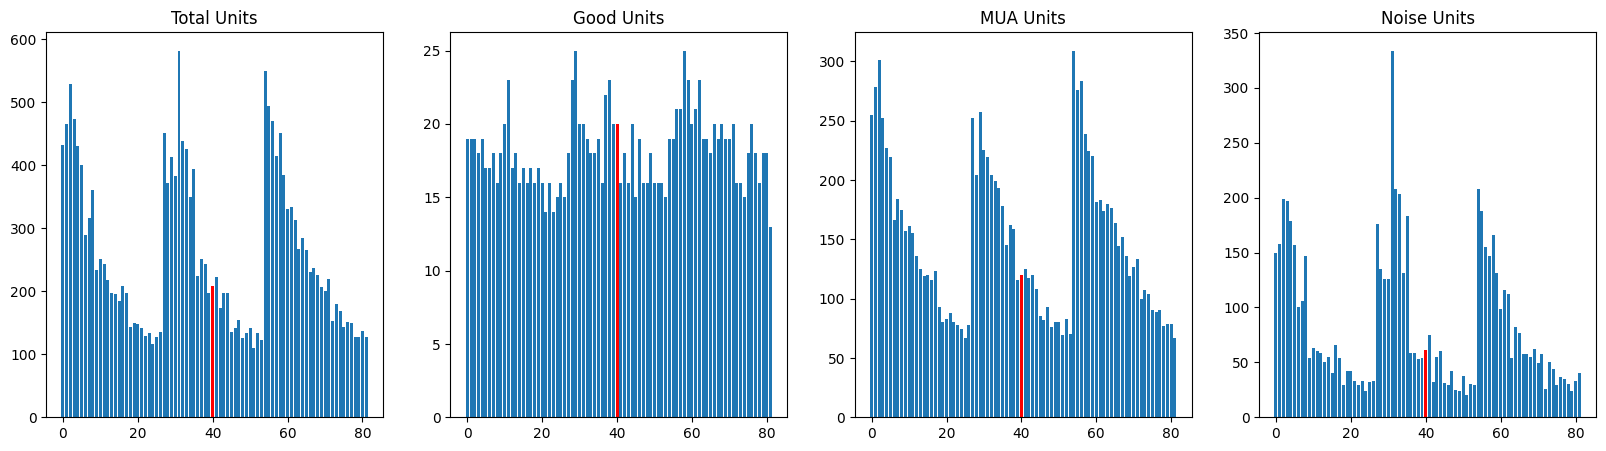

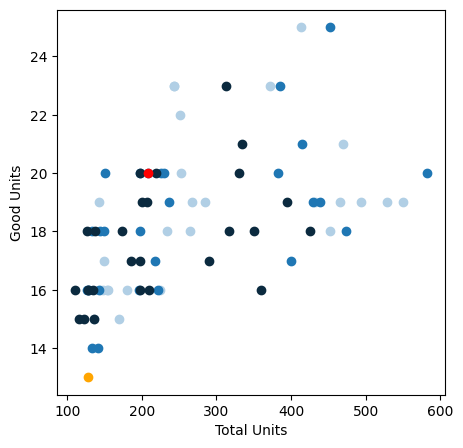

In [115]:
"""Plot the results"""
shades = three_shades("#1f77b4")

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].bar(range(len(results['unit_num'])), results['unit_num'])
axs[0].bar(used_it, results['unit_num'][used_it], color='red')  # Highlight the used iteration
axs[0].set_title('Total Units')
axs[1].bar(range(len(results['n_good_units'])), results['n_good_units'])
axs[1].bar(used_it, results['n_good_units'][used_it], color='red')  # Highlight the used iteration
axs[1].set_title('Good Units')
axs[2].bar(range(len(results['n_mua_units'])), results['n_mua_units'])
axs[2].bar(used_it, results['n_mua_units'][used_it], color='red')  # Highlight the used iteration
axs[2].set_title('MUA Units')
axs[3].bar(range(len(results['n_noise_units'])), results['n_noise_units'])
axs[3].bar(used_it, results['n_noise_units'][used_it], color='red')  # Highlight the used iteration
axs[3].set_title('Noise Units')

fig, axs = plt.subplots(1, 1, figsize=(5, 5))
use_color = np.array(pt_list) # dt_list, pt_list, nb_list
for i, val in enumerate(np.unique(use_color[:-1])):
    mask = use_color == val
    axs.scatter(np.array(results['unit_num'])[mask], np.array(results['n_good_units'])[mask], color = shades[i])
axs.scatter(results["unit_num"][used_it], results["n_good_units"][used_it], color='red')  # Highlight the used iteration
axs.scatter(results["unit_num"][-1], results["n_good_units"][-1], color='orange')  # Highlight the default iteration
axs.set_xlabel('Total Units')
axs.set_ylabel('Good Units')

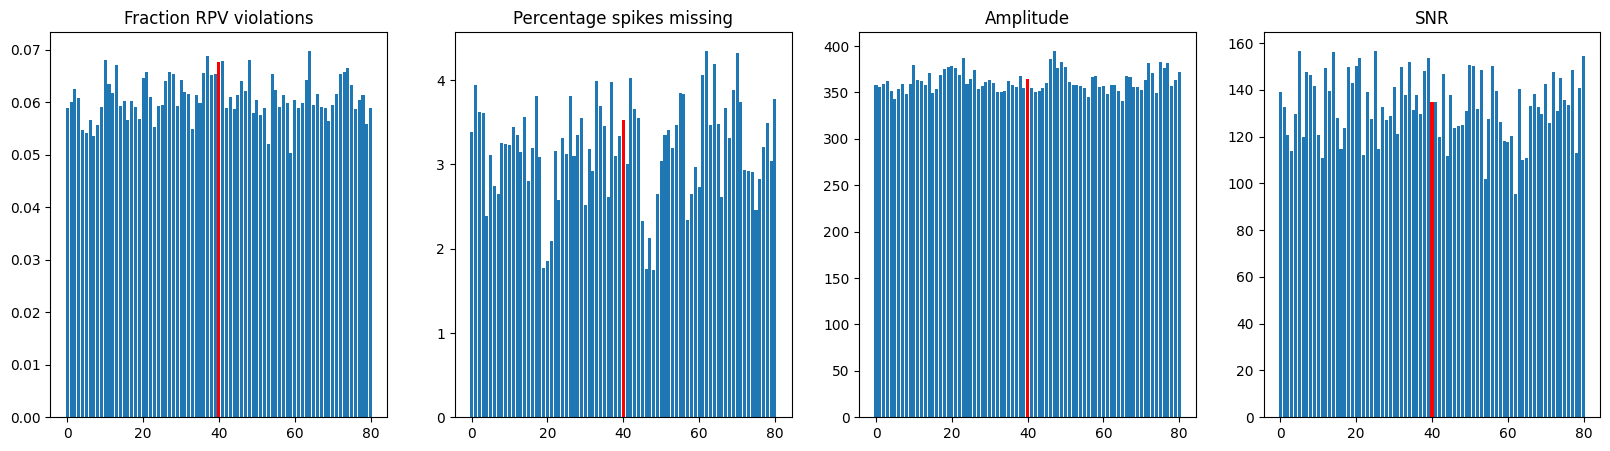

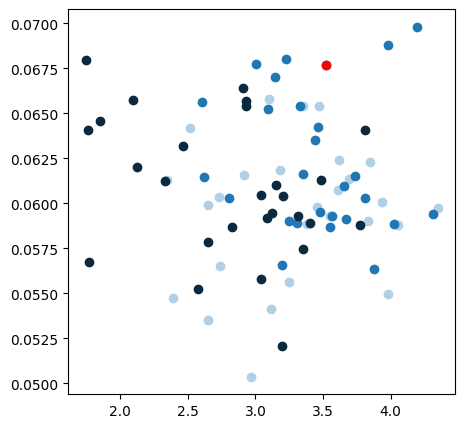

In [64]:
bc_metrics = {"spikes_missing":[], "rpv":[], "amplitude":[], "snr":[]}

for mouse in ["JAL007"]:#["JAL004","JAL005","JAL006","JAL007","JAL008"]: # "JAL003", 
    mouse_folder = os.path.join(base_path, mouse)
    for session in os.listdir(mouse_folder):
        session_folder = os.path.join(mouse_folder, session)
        # find dir that end in "_g0"
        if os.path.isdir(session_folder):
            for d in os.listdir(session_folder):
                if os.path.isdir(os.path.join(session_folder, d)) and d.endswith("_g0"):
                    imec_folder = os.path.join(session_folder, d, d + "_imec0")
                    for e in os.listdir(imec_folder):
                        if e == "KS_sweep":
                            raw_file = os.path.join(imec_folder, d + "_t0.imec0.ap.bin")
                            meta_file = os.path.join(imec_folder, d + "_t0.imec0.ap.meta")
                            for run in os.listdir(os.path.join(imec_folder, e)):
                                if "run" not in run:
                                    continue
                                ks_dir = os.path.join(imec_folder, e, run, "sorter_output", "sorter_output")

                                types = pd.read_csv(os.path.join(ks_dir, "cluster_bc_unitType.tsv"), sep='\t')
                                # chosen = np.ones(len(types), dtype=bool)  
                                chosen = types['bc_unitType'].to_numpy() == "GOOD"
                                rpv = pd.read_csv(os.path.join(ks_dir, "cluster_fractionRPVs_estimatedTauR.tsv"), sep='\t')
                                bc_metrics["rpv"].append(np.nanpercentile(rpv['fractionRPVs_estimatedTauR'].to_numpy()[chosen], 90))
                                sm = pd.read_csv(os.path.join(ks_dir, "cluster_percentageSpikesMissing_gaussian.tsv"), sep='\t')
                                bc_metrics["spikes_missing"].append(np.nanpercentile(sm['percentageSpikesMissing_gaussian'].to_numpy()[chosen], 90))
                                bc_metrics["amplitude"].append(np.nanpercentile(pd.read_csv(os.path.join(ks_dir, "cluster_rawAmplitude.tsv"), sep='\t')['rawAmplitude'].to_numpy()[chosen], 90))
                                bc_metrics["snr"].append(np.nanpercentile(pd.read_csv(os.path.join(ks_dir, "cluster_signalToNoiseRatio.tsv"), sep='\t')['signalToNoiseRatio'].to_numpy()[chosen], 90))

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].bar(range(len(bc_metrics['rpv'])), bc_metrics['rpv'])
axs[0].bar(used_it, bc_metrics['rpv'][used_it], color='red')  # Highlight the used iteration
axs[0].set_title('Fraction RPV violations')
axs[1].bar(range(len(bc_metrics['spikes_missing'])), bc_metrics['spikes_missing'])
axs[1].bar(used_it, bc_metrics['spikes_missing'][used_it], color='red')  # Highlight the used iteration
axs[1].set_title('Percentage spikes missing')
axs[2].bar(range(len(bc_metrics['amplitude'])), bc_metrics['amplitude'])
axs[2].bar(used_it, bc_metrics['amplitude'][used_it], color='red')  # Highlight the used iteration
axs[2].set_title('Amplitude')
axs[3].bar(range(len(bc_metrics['snr'])), bc_metrics['snr'])
axs[3].bar(used_it, bc_metrics['snr'][used_it], color='red')  # Highlight the used iteration
axs[3].set_title('SNR')      

fig, axs = plt.subplots(1, 1, figsize=(5, 5))
use_color = np.array(auc_list) # dt_list, pt_list, nb_list, auc_list
for i, val in enumerate(np.unique(use_color)):
    mask = use_color == val
    axs.scatter(np.array(bc_metrics['spikes_missing'])[mask], np.array(bc_metrics['rpv'])[mask], color=shades[i])
axs.scatter(bc_metrics["spikes_missing"][used_it], bc_metrics["rpv"][used_it], color='red')  # Highlight the used iteration

In [ ]:
spike_times = np.load(r"Z:\Jasmine_Laurence\Experimental_Data\JAL007\JAL007_shelter_barrier_flip_7_2024_04_04T11_03_24\barrier_flip7_g0\barrier_flip7_g0_imec0\SI_KS_output\sorter_output\spike_times.npy")
spike_clusters = np.load(r"Z:\Jasmine_Laurence\Experimental_Data\JAL007\JAL007_shelter_barrier_flip_7_2024_04_04T11_03_24\barrier_flip7_g0\barrier_flip7_g0_imec0\SI_KS_output\sorter_output\spike_clusters.npy")
cluster_group = np.loadtxt(r"Z:\Jasmine_Laurence\Experimental_Data\JAL007\JAL007_shelter_barrier_flip_7_2024_04_04T11_03_24\barrier_flip7_g0\barrier_flip7_g0_imec0\SI_KS_output\sorter_output\cluster_bc_unitType.tsv", dtype=str, delimiter="\t", skiprows=1)

import numpy as np

# sort globally by time (recommended if not guaranteed sorted)
order = np.argsort(spike_times, kind="mergesort")
t = spike_times[order]
c = spike_clusters[order]

# parameters
fs = 30000.0               # sampling rate Hz (set correctly!)
censored_period_ms = 0.3
thr = int(round(censored_period_ms * 1e-3 * fs))  # samples

keep = np.ones(t.shape[0], dtype=bool)

# remove duplicates within each cluster: keep first spike in refractory window
for clu in np.unique(c):
    group = cluster_group[cluster_group[:, 0] == str(clu)][0][1]
    if group == 'GOOD':
        idx = np.flatnonzero(c == clu)
        tt = t[idx]
        dt = np.diff(tt)
        dup = dt <= thr
        # mark later spike as duplicate
        keep[idx[1:][dup]] = False

# t_clean = t[keep]
# c_clean = c[keep]


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [86]:
spike_times

array([[       95],
       [      103],
       [      122],
       ...,
       [397934512],
       [397934516],
       [397934520]], shape=(68820588, 1), dtype=uint64)

In [76]:
fs = 30000.0               # sampling rate Hz (set correctly!)
censored_period_ms = 13
thr = int(round(censored_period_ms * 1e-3 * fs))  # samples
idx = np.flatnonzero(c == clu)
tt = t[idx]
dt = np.diff(tt)
dup = dt <= thr
dup

array([], shape=(68820588, 1, 0), dtype=bool)